## Partie 1 : Analyse exploratoire des données
Chargement du jeu de données, inspection des valeurs manquantes, suppression des colonnes inutiles et visualisation de la distribution de la variable cible.

--- Aperçu des premières lignes ---
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  per

C:\Users\adjara\AppData\Local\Temp\ipykernel_15840\524303650.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='magma')


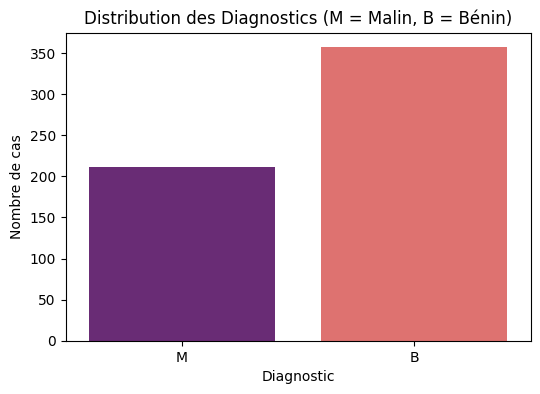

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du fichier depuis ton sous-dossier exact
chemin = 'archive (1)/data.csv'
df = pd.read_csv(chemin)

print("--- Aperçu des premières lignes ---")
print(df.head())

print("\n--- Informations et Valeurs Manquantes ---")
print(df.info())

# Nettoyage : Suppression des colonnes inutiles (l'id et la colonne vide générée à la fin)
colonnes_a_supprimer = ['id', 'Unnamed: 32']
for col in colonnes_a_supprimer:
    if col in df.columns:
        df = df.drop(columns=[col])

# Création du graphique de distribution demandé avec la palette magma
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', palette='magma')
plt.title('Distribution des Diagnostics (M = Malin, B = Bénin)')
plt.xlabel('Diagnostic')
plt.ylabel('Nombre de cas')
plt.show()

## Partie 2 : Prétraitement des données
Comptage des classes uniques, encodage numérique de la colonne cible (M -> 1, B -> 0), division des données et standardisation des caractéristiques.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Comptage des valeurs uniques pour la colonne de diagnostic
print("--- Comptage des lignes uniques ---")
print(df['diagnosis'].value_counts())

# Encodage : conversion des catégories en valeurs numériques
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Séparation des variables explicatives et de la cible
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Division des données (80% pour l'entraînement, 20% pour le test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisation des caractéristiques pour les modèles sensibles à l'échelle
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Statut ---")
print(f"Données prêtes. Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")